# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030


# Exercise 2 — SVM: Spam Email Classification

**Scenario:** An online company wants to classify emails as **spam** or **not spam** using
features such as word frequency (how often certain spammy keywords appear) and message length.

We'll build a synthetic email dataset with features in the spirit of the classic UCI
"Spambase" dataset — frequencies of common spam trigger words, punctuation frequency, capital-letter
usage, and message length — then train a **Support Vector Machine** classifier and evaluate it.




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Generate a representative spam-detection dataset

Features (per email):
- `freq_free`, `freq_win`, `freq_offer`, `freq_click` — frequency (%) of spam-trigger words
- `freq_exclaim` — frequency (%) of `!` characters
- `pct_capitals` — percentage of capital letters in the message
- `num_links` — number of hyperlinks
- `message_length` — total character count

Spam emails tend to be shorter, use more spam-trigger words, more exclamation marks, more capital
letters, and more links than legitimate emails.


In [2]:
def generate_spam_data(n=800, seed=42):
    rng = np.random.default_rng(seed)

    is_spam = rng.binomial(1, 0.35, n)  # ~35% spam, realistic class imbalance

    def draw(mean_ham, mean_spam, low=0):
        # Wider gamma shape (more spread) so ham/spam distributions overlap realistically
        mean = np.where(is_spam == 1, mean_spam, mean_ham)
        return rng.gamma(shape=1.3, scale=mean / 1.3, size=n).clip(low, None)

    freq_free    = draw(0.15, 0.55)
    freq_win     = draw(0.08, 0.40)
    freq_offer   = draw(0.10, 0.35)
    freq_click   = draw(0.12, 0.45)
    freq_exclaim = draw(0.25, 0.70)
    pct_capitals = draw(4.0, 12.0).clip(0, 100)
    num_links    = rng.poisson(np.where(is_spam == 1, 2.6, 1.1))
    message_length = rng.normal(np.where(is_spam == 1, 480, 780),
                                 np.where(is_spam == 1, 260, 420)).clip(30, None)

    # Add independent feature noise so no single feature perfectly separates the classes
    for arr in [freq_free, freq_win, freq_offer, freq_click, freq_exclaim]:
        arr += rng.normal(0, 0.12, n)
        np.clip(arr, 0, None, out=arr)

    df = pd.DataFrame({
        "freq_free": freq_free.round(3),
        "freq_win": freq_win.round(3),
        "freq_offer": freq_offer.round(3),
        "freq_click": freq_click.round(3),
        "freq_exclaim": freq_exclaim.round(3),
        "pct_capitals": pct_capitals.round(1),
        "num_links": num_links,
        "message_length": message_length.round(0).astype(int),
        "is_spam": is_spam,
    })
    return df


df = generate_spam_data(800, seed=RANDOM_STATE)
print("Rows:", len(df), " | Spam rate:", round(df["is_spam"].mean(), 3))
df.head()


Rows: 800  | Spam rate: 0.35


,freq_free,freq_win,freq_offer,freq_click,freq_exclaim,pct_capitals,num_links,message_length,is_spam
0,1.423,0.154,0.064,0.685,1.036,6.2,0,367,1
1,0.175,0.016,0.147,0.386,0.559,4.2,0,405,0
2,0.439,0.158,0.395,0.429,0.231,12.2,3,422,1
3,0.146,0.609,0.343,0.674,1.220,8.3,4,30,1
4,0.188,0.000,0.210,0.086,1.104,0.7,1,606,0


## 2. Explore the data

In [3]:
df.describe()


,freq_free,freq_win,freq_offer,freq_click,freq_exclaim,pct_capitals,num_links,message_length,is_spam
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000
mean,0.290888,0.209558,0.195906,0.277839,0.422266,6.79300,1.587500,666.260000,0.350000
std,0.351428,0.263729,0.225055,0.339468,0.448991,7.95691,1.460311,404.303304,0.477268
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.10000,0.000000,30.000000,0.000000
25%,0.067000,0.025000,0.023750,0.052000,0.124750,1.90000,0.750000,364.250000,0.000000
50%,0.186000,0.132500,0.134500,0.170000,0.272000,4.40000,1.000000,623.000000,0.000000
75%,0.375250,0.275000,0.286000,0.372000,0.559000,8.20000,2.000000,917.500000,1.000000
max,2.448000,1.942000,1.625000,2.527000,2.706000,82.20000,8.000000,2051.000000,1.000000


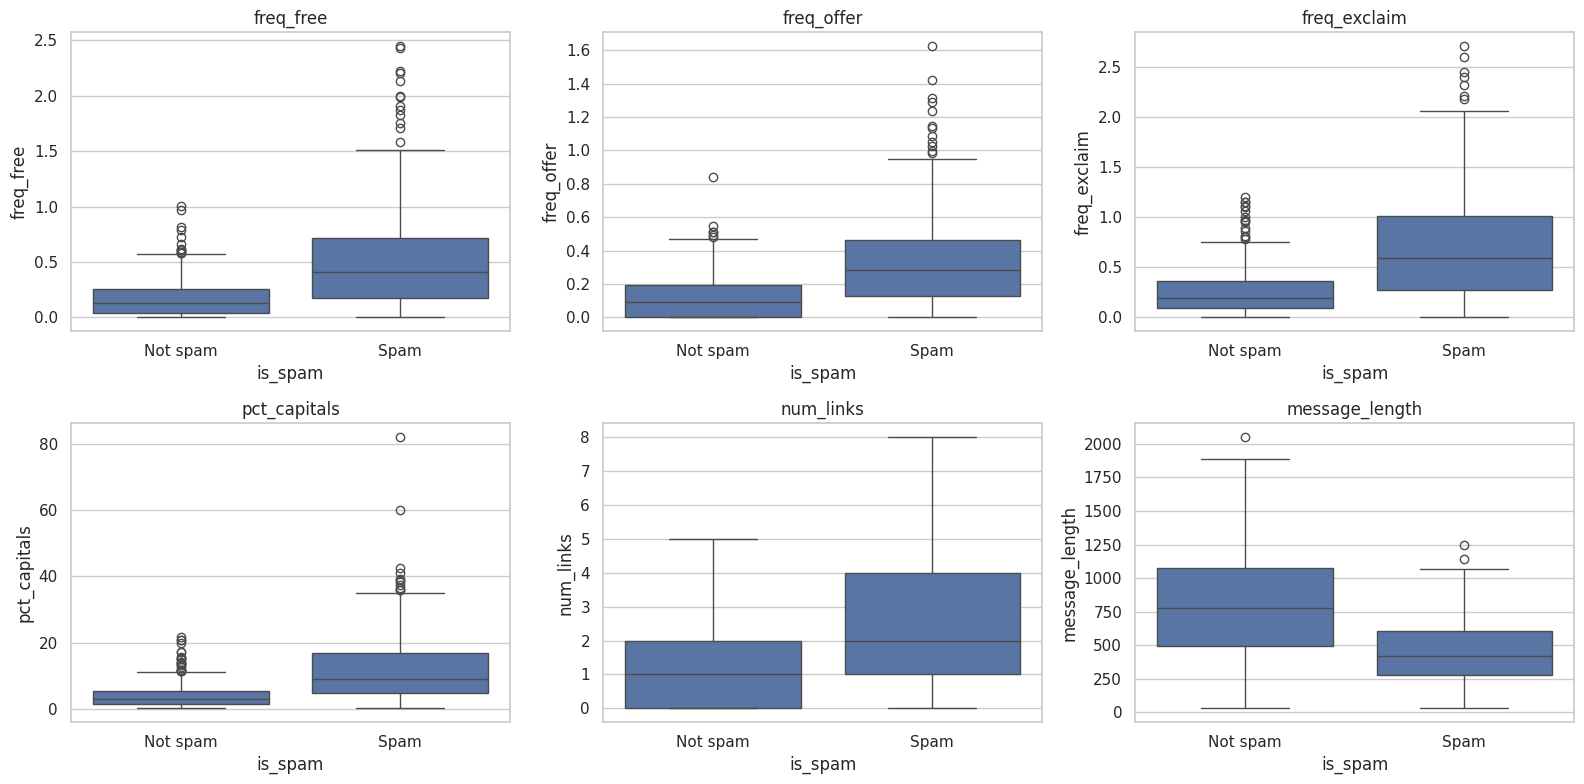

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
feature_cols = ["freq_free", "freq_offer", "freq_exclaim", "pct_capitals", "num_links", "message_length"]

for ax, col in zip(axes.flat, feature_cols):
    sns.boxplot(data=df, x="is_spam", y=col, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Not spam", "Spam"])
    ax.set_title(col)

plt.tight_layout()
plt.show()


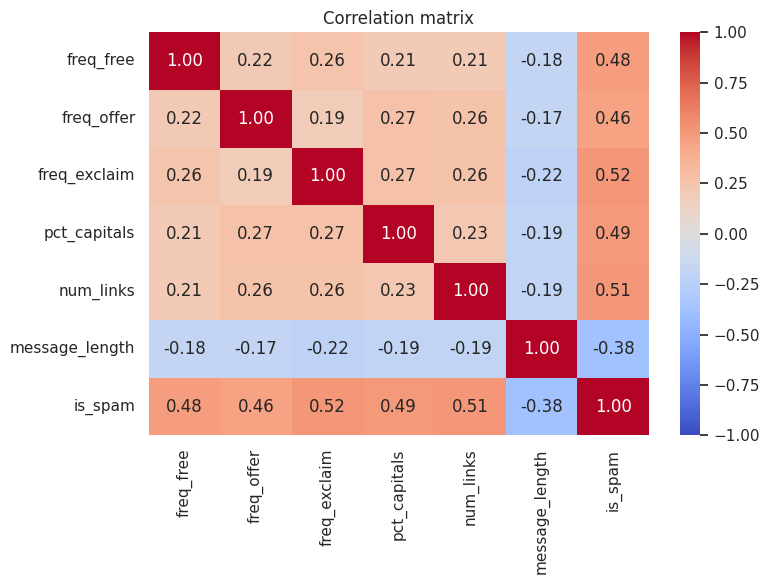

In [5]:
plt.figure(figsize=(8, 6))
corr_cols = feature_cols + ["is_spam"]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()


## 3. Train / test split and feature scaling

SVMs are distance-based, so scaling features to a common range is important.

In [6]:
feature_cols = ["freq_free", "freq_win", "freq_offer", "freq_click",
                 "freq_exclaim", "pct_capitals", "num_links", "message_length"]
X = df[feature_cols]
y = df["is_spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


## 4. Tune and train the SVM classifier

We use `GridSearchCV` to search over kernel type and regularization strength `C` (and `gamma` for
the RBF kernel), selecting the combination with the best cross-validated accuracy.


In [7]:
param_grid = [
    {"kernel": ["linear"], "C": [0.1, 1, 10]},
    {"kernel": ["rbf"], "C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.1]},
]

grid = GridSearchCV(SVC(probability=True, random_state=RANDOM_STATE),
                     param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_s, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 3))

svm_clf = grid.best_estimator_


Best parameters: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV accuracy: 0.96


## 5. Evaluate on the held-out test set

In [8]:
y_pred = svm_clf.predict(X_test_s)
y_proba = svm_clf.predict_proba(X_test_s)[:, 1]

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC-AUC      :", round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred, target_names=["Not spam", "Spam"]))


Test accuracy: 0.955
ROC-AUC      : 0.989

              precision    recall  f1-score   support

    Not spam       0.94      0.99      0.97       130
        Spam       0.98      0.89      0.93        70

    accuracy                           0.95       200
   macro avg       0.96      0.94      0.95       200
weighted avg       0.96      0.95      0.95       200



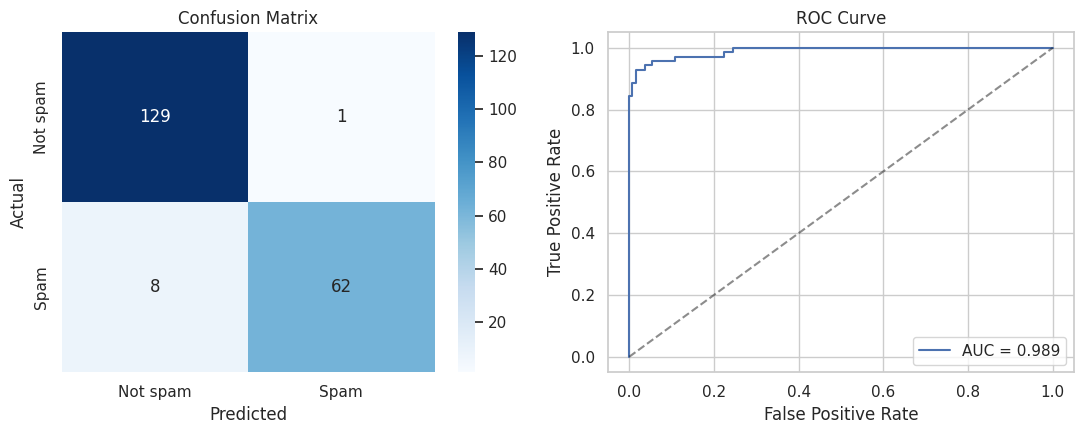

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not spam", "Spam"], yticklabels=["Not spam", "Spam"], ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Which features matter most?

For a **linear-kernel** SVM, the magnitude of the learned coefficients directly reflects each
feature's influence on the decision boundary (after standardization, coefficients are comparable
across features). If the best model uses a non-linear kernel, we instead report **permutation
importance**, which works for any kernel.


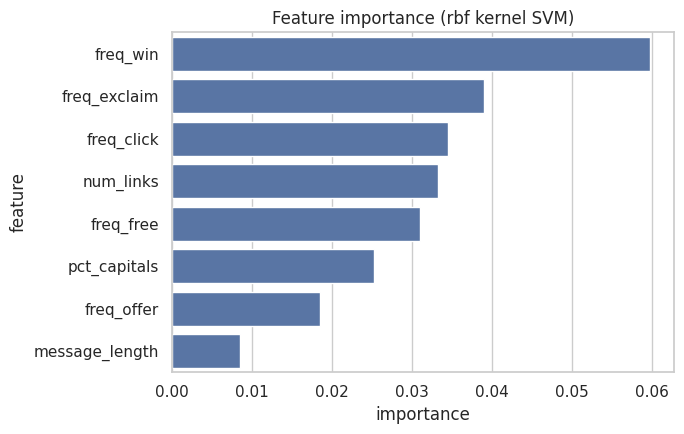

,feature,importance
1,freq_win,0.05975
4,freq_exclaim,0.03900
3,freq_click,0.03450
6,num_links,0.03325
0,freq_free,0.03100
5,pct_capitals,0.02525
2,freq_offer,0.01850
7,message_length,0.00850


In [10]:
from sklearn.inspection import permutation_importance

if svm_clf.kernel == "linear":
    coef_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": svm_clf.coef_[0]
    }).sort_values("importance", key=abs, ascending=False)
else:
    perm = permutation_importance(svm_clf, X_test_s, y_test, n_repeats=20,
                                   random_state=RANDOM_STATE, scoring="accuracy")
    coef_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": perm.importances_mean
    }).sort_values("importance", ascending=False)

plt.figure(figsize=(7, 4.5))
sns.barplot(data=coef_df, x="importance", y="feature", color="#4C72B0")
plt.title(f"Feature importance ({svm_clf.kernel} kernel SVM)")
plt.tight_layout()
plt.show()

coef_df


## 7. Classify a new incoming email

In [11]:
new_email = pd.DataFrame({
    "freq_free": [0.9],
    "freq_win": [0.6],
    "freq_offer": [0.5],
    "freq_click": [0.7],
    "freq_exclaim": [1.2],
    "pct_capitals": [22.0],
    "num_links": [5],
    "message_length": [280],
})

new_email_scaled = scaler.transform(new_email[feature_cols])
pred = svm_clf.predict(new_email_scaled)[0]
proba = svm_clf.predict_proba(new_email_scaled)[0]

print(f"Prediction: {'SPAM' if pred == 1 else 'NOT SPAM'}")
print(f"P(Not spam)={proba[0]:.1%}   P(Spam)={proba[1]:.1%}")


Prediction: SPAM
P(Not spam)=0.0%   P(Spam)=100.0%
